In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv('creditcard.csv')

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [8]:
print("No.of Rows : ",df.shape[0],"No .of col : ",df.shape[1])


No.of Rows :  284807 No .of col :  31


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [12]:
print("--- Missing_Values ---")
print(df.isna().sum())

print("\n--- Duplicated Values ---")
print(df.duplicated().sum())

--- Missing_Values ---
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

--- Duplicated Values ---
1081


In [14]:
df = df.drop_duplicates()

In [16]:
df['Class'].value_counts(normalize=True) * 100

Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64

In [18]:
df.dtypes

Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

In [20]:
print("--- Normal Transactions ---")
print(df[df['Class'] == 0]['Amount'].describe())

print("\n--- Fraud Transactions ---")
print(df[df['Class'] == 1]['Amount'].describe())

--- Normal Transactions ---
count    283253.000000
mean         88.413575
std         250.379023
min           0.000000
25%           5.670000
50%          22.000000
75%          77.460000
max       25691.160000
Name: Amount, dtype: float64

--- Fraud Transactions ---
count     473.000000
mean      123.871860
std       260.211041
min         0.000000
25%         1.000000
50%         9.820000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64


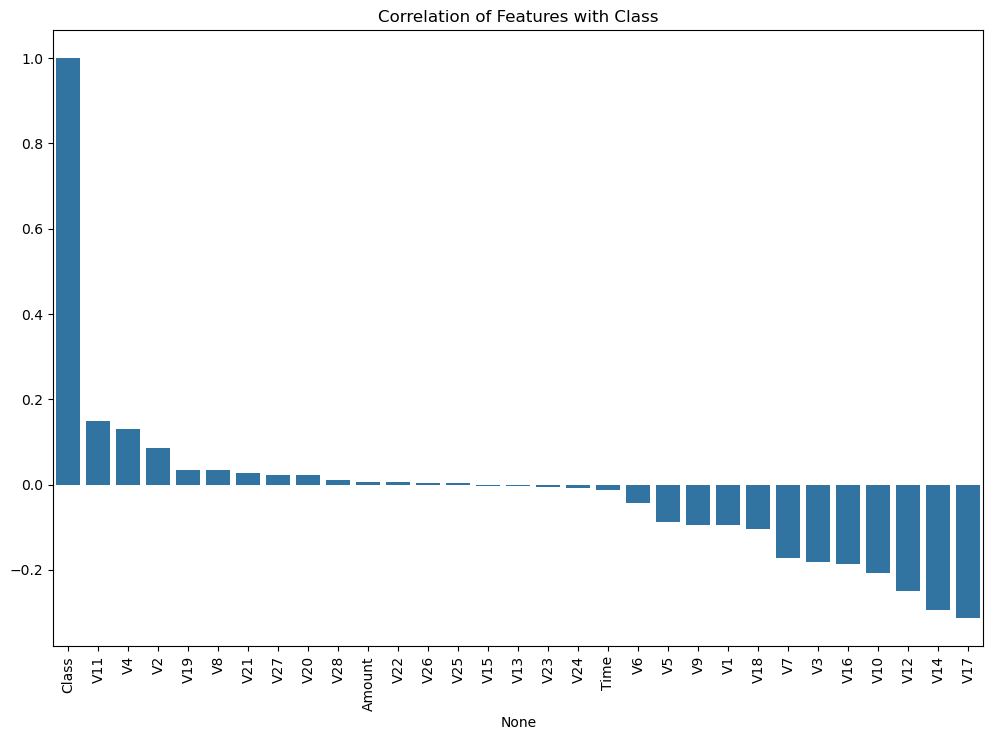

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

correlation = df.corr()['Class'].sort_values(ascending=False)
sns.barplot(x=correlation.index, y=correlation.values)
plt.xticks(rotation=90)
plt.title("Correlation of Features with Class")
plt.show()

In [24]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

df['scaled_amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1, 1))
df['scaled_time'] = scaler.fit_transform(df['Time'].values.reshape(-1, 1))

df.drop(['Time', 'Amount'], axis=1, inplace=True)

df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,scaled_amount,scaled_time
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,1.774718,-0.995290
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,-0.268530,-0.995290
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,4.959811,-0.995279
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0,1.411487,-0.995279
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0,0.667362,-0.995267


In [26]:
X = df.drop('Class', axis=1)

y = df['Class']

In [30]:
from sklearn.model_selection import train_test_split

# Split dataset into 80% training and 20% testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (226980, 30)
X_test shape: (56746, 30)


In [32]:
from sklearn.linear_model import LogisticRegression

# Initialize Logistic Regression with balanced class weights
model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

# Train the model
model.fit(X_train, y_train)

# Predict on test data
y_pred = model.predict(X_test)

In [34]:
from sklearn.metrics import classification_report, confusion_matrix

# Print Confusion Matrix
print("--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred))

# Print Classification Report
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

--- Confusion Matrix ---
[[55262  1389]
 [   12    83]]

--- Classification Report ---
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56651
           1       0.06      0.87      0.11        95

    accuracy                           0.98     56746
   macro avg       0.53      0.92      0.55     56746
weighted avg       1.00      0.98      0.99     56746



In [39]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Initialize Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# Train the model
rf_model.fit(X_train, y_train)

# Predict on test data
y_pred_rf = rf_model.predict(X_test)

# Evaluate results
print("--- Random Forest Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred_rf))

print("\n--- Random Forest Classification Report ---")
print(classification_report(y_test, y_pred_rf))

--- Random Forest Confusion Matrix ---
[[56649     2]
 [   25    70]]

--- Random Forest Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.97      0.74      0.84        95

    accuracy                           1.00     56746
   macro avg       0.99      0.87      0.92     56746
weighted avg       1.00      1.00      1.00     56746



In [41]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# Get prediction probabilities for class 1
y_probs = rf_model.predict_proba(X_test)[:, 1]

# Try a custom threshold (e.g., 0.30)
custom_threshold = 0.30
y_pred_custom = (y_probs >= custom_threshold).astype(int)

# Evaluate results with new threshold
print(f"--- Results with Threshold = {custom_threshold} ---")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_custom))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_custom))

--- Results with Threshold = 0.3 ---
Confusion Matrix:
[[56642     9]
 [   24    71]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.89      0.75      0.81        95

    accuracy                           1.00     56746
   macro avg       0.94      0.87      0.91     56746
weighted avg       1.00      1.00      1.00     56746



In [43]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Apply SMOTE only on training data to prevent data leakage
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Initialize and train Random Forest on balanced data
rf_smote = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
rf_smote.fit(X_train_resampled, y_train_resampled)

# Predict on original test data
y_pred_smote = rf_smote.predict(X_test)

# Evaluate results
print("--- Random Forest + SMOTE Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred_smote))

print("\n--- Random Forest + SMOTE Classification Report ---")
print(classification_report(y_test, y_pred_smote))

--- Random Forest + SMOTE Confusion Matrix ---
[[56644     7]
 [   23    72]]

--- Random Forest + SMOTE Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.91      0.76      0.83        95

    accuracy                           1.00     56746
   macro avg       0.96      0.88      0.91     56746
weighted avg       1.00      1.00      1.00     56746



In [48]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Calculate class ratio for scale_pos_weight
# sum(negative instances) / sum(positive instances)
ratio = (y_train == 0).sum() / (y_train == 1).sum()

# Initialize XGBoost with scale_pos_weight
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    scale_pos_weight=ratio,
    random_state=42,
    n_jobs=-1
)

# Train the model
xgb_model.fit(X_train, y_train)

# Predict on test data
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate results
print("--- XGBoost Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred_xgb))

print("\n--- XGBoost Classification Report ---")
print(classification_report(y_test, y_pred_xgb))

--- XGBoost Confusion Matrix ---
[[56633    18]
 [   19    76]]

--- XGBoost Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.81      0.80      0.80        95

    accuracy                           1.00     56746
   macro avg       0.90      0.90      0.90     56746
weighted avg       1.00      1.00      1.00     56746



In [47]:
# Install xgboost library in the current Jupyter environment
!pip install xgboost

   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/48.9 MB ? eta -:--:--
    --------------------------------------- 0.8/48.9 MB 1.7 MB/s eta 0:00:29
    --------------------------------------- 1.0/48.9 MB 1.8 MB/s eta 0:00:27
   - -------------------------------------- 1.3/48.9 MB 1.5 MB/s eta 0:00:33
   - -------------------------------------- 1.8/48.9 MB 1.7 MB/s eta 0:00:29
   - -------------------------------------- 2.1/48.9 MB 1.7 MB/s eta 0:00:28
   -- ------------------------------------- 2.6/48.9 MB 1.7 MB/s eta 0:00:27
   -- ------------------------------------- 3.1/48.9 MB 1.8 MB/s eta 0:00:26
   -- ------------------------------------- 3.4/48.9 MB 1.8 MB/s eta 0:00:26
   --- ------------------------------------ 3.9/48.9 MB 1.8 MB/s eta 0:00:25
   --- ------------------------------------ 4.2/48.9 MB 1.8 MB/s eta 0:00:25
   --- -------------

In [51]:
# Try tuning scale_pos_weight for better precision-recall balance
xgb_balanced = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    scale_pos_weight=15, # Lower weight to boost precision
    random_state=42,
    n_jobs=-1
)

xgb_balanced.fit(X_train, y_train)
y_pred_bal = xgb_balanced.predict(X_test)

print("--- XGBoost (Tuned Weight) Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred_bal))

print("\n--- XGBoost (Tuned Weight) Classification Report ---")
print(classification_report(y_test, y_pred_bal))

--- XGBoost (Tuned Weight) Confusion Matrix ---
[[56646     5]
 [   23    72]]

--- XGBoost (Tuned Weight) Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.94      0.76      0.84        95

    accuracy                           1.00     56746
   macro avg       0.97      0.88      0.92     56746
weighted avg       1.00      1.00      1.00     56746

